# Лабораторная работа
## Обратная задача для уравнения теплопроводности

Цель: восстановить начальное распределение температуры `u0(x)` по известному конечному состоянию `u(x, T)`.

В работе используется:
- решение прямой задачи (конечно-разностная схема)
- дискретное синусное преобразование (DST)
- регуляризация Тихонова
- восстановление начальной функции (IDST)



# Теоретическая часть

## Уравнение теплопроводности (прямая задача)

Рассматривается начально‑краевая задача для уравнения теплопроводности:
$$
u_t = a^2 u_xx,   (x,t) ∈ (0,l) × (0,T)
$$
Начальное условие:
$$
u(x,0) = u0(x)
$$
Граничные условия:
$$
u(0,t)=0,   u(l,t)=0,   t ∈ [0,T]
$$
Известно, что решение можно представить в виде ряда Фурье:
$$
u(x,t) = Σ c_n * exp(-λ_n a² t) * sin(π n x / l)
$$
где
$$
c_n = (2/l) ∫₀ˡ u0(x) sin(π n x / l) dx
$$
$$
λ_n = π² n² / l²
$$
---

## Обратная задача

Необходимо восстановить начальное распределение температуры $u0(x)$,
если известно конечное состояние системы:
$$
u(x,T)
$$
Из решения следует, что коэффициенты Фурье для $u(x,T)$:
$$
d_n = c_n exp(-λ_n a² T)
$$
Следовательно
$$
c_n = d_n exp(λ_n a² T)
$$
Однако такое восстановление является **неустойчивым**, поскольку
малые ошибки в $d_n$ приводят к экспоненциальному росту ошибки в $c_n$.

Это связано с тем, что $λ_n ~ n²$ и высокочастотные гармоники
быстро усиливают шум.

---

## Регуляризация Тихонова

Для стабилизации решения применяется регуляризация Тихонова.
Экспоненциальный множитель заменяется фильтрующей функцией:
$$
H_α(λ_n) = exp(λ_n a² T) / (1 + α exp(2 λ_n a² T))
$$
где $α$ — параметр регуляризации.

Свойства:

1. При $α → 0$ фильтр стремится к $exp(λ_n a² T)$
2. Высокие частоты подавляются
3. Низкие частоты практически не искажаются

Таким образом регуляризация позволяет получить устойчивое приближение
начальной функции.


## Импорт библиотек
Нам понадобятся библиотеки для:
- численных вычислений
- построения графиков
- синусных преобразований

In [1]:
# numpy — работа с массивами и численные вычисления
import numpy as np

# matplotlib — построение графиков
import matplotlib.pyplot as plt

# из scipy используем DST и обратное DST
# DST — дискретное синусное преобразование
# IDST — обратное синусное преобразование
from scipy.fft import dst, idst
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 12

## Параметры задачи
Задаём параметры области и сетки.

In [2]:
# длина стержня
l = 1

# конечное время
T = 0.05

# коэффициент теплопроводности
a = 1

# число узлов по пространству
Nx = 50

# число шагов по времени
Nt = 2000

# шаг по пространству
dx = l / Nx

# шаг по времени
dt = T / Nt

# координаты пространственной сетки
x = np.linspace(0, l, Nx+1)

## Начальная функция
Выбираем тестовую функцию `u0(x)`.

Она используется только для генерации данных прямой задачи.
Затем мы будем пытаться восстановить её по конечному состоянию.

In [3]:
# функция начального распределения температуры
def initial_function(x):
    return x*(1-x)

# создаём массив для хранения решения
# строки — время
# столбцы — координата
u = np.zeros((Nt+1, Nx+1))

# задаём начальное условие
u[0,:] = initial_function(x)

# граничные условия
# температура на концах стержня равна нулю
u[:,0] = 0
u[:,-1] = 0

## Решение прямой задачи
Используем явную конечно-разностную схему.

In [4]:
# коэффициент схемы
r = a**2 * dt / dx**2

# проверяем условие устойчивости (условие Куранта)
print('Courant number =', r)

# основной цикл по времени
for n in range(Nt):
    
    # цикл по пространству
    # пропускаем граничные точки
    for i in range(1, Nx):
        
        # явная разностная схема
        u[n+1,i] = u[n,i] + r*(u[n,i+1] - 2*u[n,i] + u[n,i-1])

# конечное состояние системы
uT = u[-1,:]

Courant number = 0.0625


## График конечного состояния

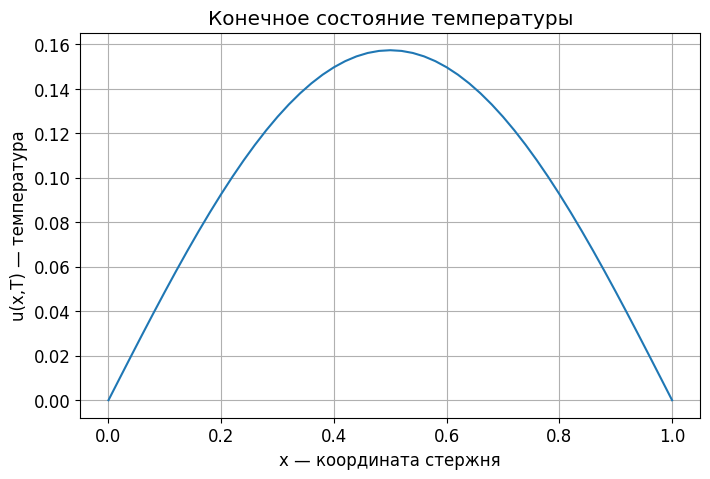

In [5]:
plt.figure()

plt.plot(x, uT)

plt.title("Конечное состояние температуры")
plt.xlabel("x — координата стержня")
plt.ylabel("u(x,T) — температура")

plt.grid()
plt.show()

## DST преобразование
Находим коэффициенты Фурье для функции `u(x,T)`.

In [6]:
# используем внутренние точки (без границ)
d = dst(uT[1:-1], type=1)

## Регуляризация Тихонова
Используем фильтр для подавления высокочастотных компонент.

In [7]:
# номера гармоник
n = np.arange(1, Nx)

# собственные значения оператора
lam = (np.pi*n/l)**2

# параметр регуляризации
alpha = 1e-3

# вычисление коэффициентов
# формула переписана в устойчивом виде
c = d / (np.exp(-lam*a**2*T) + alpha*np.exp(lam*a**2*T))

C:\Users\0potter0\AppData\Local\Temp\ipykernel_17916\527702520.py:12: RuntimeWarning: overflow encountered in exp
  c = d / (np.exp(-lam*a**2*T) + alpha*np.exp(lam*a**2*T))


## Восстановление начальной функции

In [8]:
# создаём массив для восстановленной функции
u0_rec = np.zeros(Nx+1)

# применяем обратное синусное преобразование
u0_rec[1:-1] = idst(c, type=1)/(2*(Nx))

## Сравнение решений

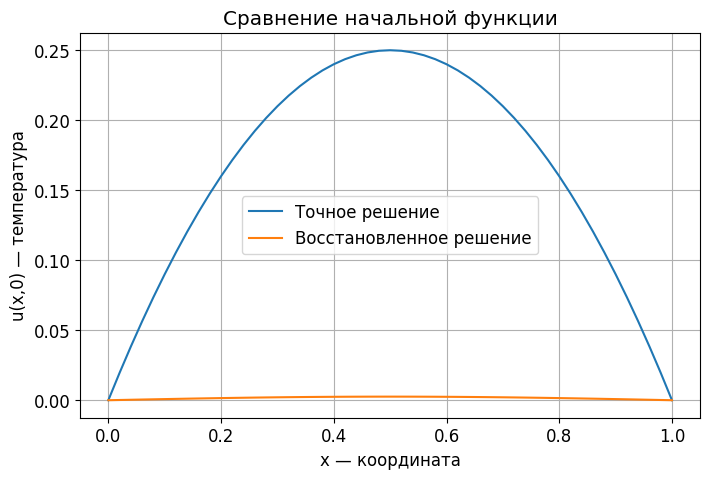

In [ ]:
plt.figure()

plt.plot(x, initial_function(x), label='Точное решение')
plt.plot(x, u0_rec, label='Восстановленное решение')

plt.title("Сравнение начальной функции")
plt.xlabel("x — координата")
plt.ylabel("u(x,0) — температура")

plt.legend()
plt.grid()
plt.show()

## Исследование параметра регуляризации
Сравним результаты для разных значений α.

C:\Users\0potter0\AppData\Local\Temp\ipykernel_17916\2273763137.py:9: RuntimeWarning: overflow encountered in exp
  c = d / (np.exp(-lam*a**2*T) + alpha*np.exp(lam*a**2*T))


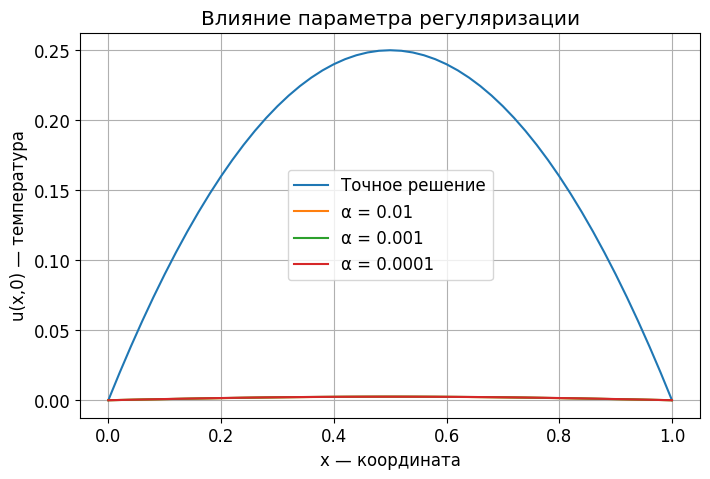

In [ ]:
alphas = [1e-2, 1e-3, 1e-4]

plt.figure()

plt.plot(x, initial_function(x), label='Точное решение')

for alpha in alphas:

    c = d / (np.exp(-lam*a**2*T) + alpha*np.exp(lam*a**2*T))

    u0_tmp = np.zeros(Nx+1)
    u0_tmp[1:-1] = idst(c, type=1)/(2*(Nx))

    plt.plot(x, u0_tmp, label=f'α = {alpha}')

plt.title("Влияние параметра регуляризации")
plt.xlabel("x — координата")
plt.ylabel("u(x,0) — температура")

plt.legend()
plt.grid()
plt.show()

## Вывод
В лабораторной работе была исследована обратная задача для уравнения теплопроводности.

Было показано, что без регуляризации задача является неустойчивой.
Использование регуляризации Тихонова позволяет подавить высокочастотные ошибки и восстановить начальную функцию.